LangChain的Runtime机制是理解Agent内部运行状态的关键。它包括三个核心概念：
| 概念 | 说明 | 生命周期 |
| --- | --- | --- |
| State | 短期记忆，存储Agent当前对话信息、任务状态 | 单次请求 |
| Store | 长期记忆，包含用户偏好、失败经验等 | 跨会话 |
| Context | 运行时上下文，传递配置参数 | 单次请求 |

本节我们将分别来学习这三个概念。

## 1. State（短期记忆）
State我们之前有学习过，它是Agent的短期记忆，存储当前会话的历史消息、任务状态等信息。

我们之前学习短期记忆时使用的是默认的AgentState，其中只包含会话的历史消息（messages），本节开始我们学习如何自定义AgentState，记录除了历史消息以外的其他信息。

### 1.1 自定义State
要自定义AgentState，其实就是定义一个类，然后继承AgentState，在其中添加想要记录的属性信息即可。

例如，我们要实现统计用户的模型调用次数、调用时间的功能，可以这样定义state：

In [1]:
from langchain.agents import AgentState
from typing import NotRequired


# 定义自定义State结构
class CustomState(AgentState):
    """Agent的任务状态"""
    model_call_count: NotRequired[int]  # 模型调用次数
    session_start: NotRequired[str]  # 会话开始时间

由于在AgentState中已经具备messages属性，也就是历史消息列表，因此我们的CustomState继承了AgentState以后，不仅可以记录会话的历史消息，也能记录Agent运行的任务状态信息了。

那么，我们该如何操作state中的自定义属性呢？

LangChain中通常有两个地方可以操作state：
- Tool
- Middleware
由于Middleware还没有学习，我们先来看在Tool中访问state

1.2 在工具中访问state
在定义tool的时候，LangChain内置了一个runtime参数，通过runtime我们可以获取Agent的内部信息，包括：
- state : dict结构
- store
- context
```python
@tool
def my_tool(runtime: ToolRuntime):
    pass
```
runtime是了LangChain中tool的限定参数，自定义参数不能叫这个名字。

在runtime中state是dict结构，我们可以这样访问state中的属性：
```python
model_call_count = runtime.state.get("model_call_count", 0)
```
而修改state则是通过返回一个update格式的Command指令，像这样：
```python
@tool
def my_tool(runtime: ToolRuntime):
    return Command(update={
        "model_call_count": 1,
        "messages": [ToolMessage("Success!", tool_call_id=runtime.tool_call_id)]
    })
```

例如，我们定义这样的一个tool：

In [ ]:
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage
from datetime import datetime


@tool
def update_state(runtime: ToolRuntime):
    """A tool that update agent state"""
    # 获取state中的历史消息
    messages = runtime.state['messages']
    # 消息数量
    message_count = len(messages)
    # 组织结果
    command = {
        "model_call_count": runtime.state.get("model_call_count", 0) + 1,
        "messages": [ToolMessage("Successfully updated agent state", tool_call_id=runtime.tool_call_id)]
    }
    # 判断是否是第一次
    if message_count <= 2:
        command['session_start'] = datetime.now()

    return Command(update=command)

### 1.3 设置state schema
定义了AgentState还不够，我们还需要在创建Agent时设定state schema，告诉Agent要使用自定义的state：

In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    "deepseek-chat",
    tools=[update_state],
    state_schema=CustomState, # 告诉Agent使用我们自定义的state
    checkpointer=InMemorySaver(),
    system_prompt="你是一个热心的助手，你需要在每次请求时调用update_state工具以更新任务状态。"
)

### 1.4 测试
完整代码如下：

In [2]:
from langchain.tools import tool, ToolRuntime
from langgraph.types import Command
from langchain.messages import ToolMessage
from datetime import datetime
from langchain.agents import AgentState
from typing import NotRequired
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv()

# 定义自定义State结构
class CustomState(AgentState):
    """Agent的任务状态"""
    model_call_count: NotRequired[int]  # 模型调用次数
    session_start: NotRequired[str]  # 会话开始时间

@tool
def update_state(runtime: ToolRuntime):
    """A tool that update agent state"""
    # 获取state中的历史消息
    messages = runtime.state['messages']
    # 消息数量
    message_count = len(messages)
    # 组织结果
    command = {
        "model_call_count": runtime.state.get("model_call_count", 0) + 1,
        "messages": [ToolMessage("Successfully updated agent state", tool_call_id=runtime.tool_call_id)]
    }
    # 判断是否是第一次
    if message_count <= 2:
        command['session_start'] = datetime.now()

    return Command(update=command)

agent = create_agent(
    "deepseek-chat",
    tools=[update_state],
    state_schema=CustomState,
    checkpointer=InMemorySaver(),
    system_prompt="你是一个热心的助手，你需要在每次请求时调用update_state工具以更新任务状态。"
)

config = {"configurable": {"thread_id": "1"}}
response = agent.invoke(
    {"messages": [HumanMessage(content="Hi, my name is 虎哥")]},
    config
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Hi, my name is 虎哥
================================== Ai Message ==================================
Tool Calls:
  update_state (call_00_mOwigmsVnUTQvuwaHXZ46712)
 Call ID: call_00_mOwigmsVnUTQvuwaHXZ46712
  Args:
================================= Tool Message =================================
Name: update_state

Successfully updated agent state
================================== Ai Message ==================================

你好，虎哥！很高兴认识你！😄

我是你的智能助手，有什么需要帮忙的吗？无论是日常问题、工作建议、学习帮助，还是闲聊，我都可以陪你聊～ 随时开口哦！


通过下面的代码可以查看state信息：

In [3]:
agent.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, my name is 虎哥', additional_kwargs={}, response_metadata={}, id='d249648a-a3fe-470d-9d5d-621531cb50d7'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 285, 'total_tokens': 312, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 285}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'a5022ffb-fe77-4ddd-824f-4a9256c7b408', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ea1eb-4fd5-7620-af7c-f675a4579457-0', tool_calls=[{'name': 'update_state', 'args': {}, 'id': 'call_00_mOwigmsVnUTQvuwaHXZ46712', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 285, 'output_tokens': 27, 'total_tokens': 312, 'input

## 2. Store（长期记忆）
store是LangChain提供的长期记忆机制，用于在不同会话间共享数据。例如：模型以外的数据、用户偏好等。
LangChain提供了多种Store的实现方式，例如：
- InMemoryStore
- PostgresStore
- RedisStore
- ...
课程中我们以InMemoryStore为例来学习。

### 2.1 Store的数据结构
Store的数据格式是JSON文档，JSON文档采用分级管理：
- Namespace（命名空间）：可以理解为一个文件夹
  - Key（键）：可以理解为文件名，必须唯一
  - Value（值）：要存储的JSON文档

首先，我们要初始化Store：

In [4]:
from langgraph.store.memory import InMemoryStore

# ==================== 1. 创建Store ====================
memory_store = InMemoryStore()

接着，我们向Store中存储数据：

In [5]:
# ==================== 2.初始化一些数据 ====================
memory_store.put(
    ("preferences",),  # namespace，是一个tuple
    "user_001",  # key，可以是任意类型
    {  # value，是JSON格式文档
        "style": "business_markdown",
        "language": "zh-CN"
    }
)

memory_store.put(("preferences",), "user_002", {
    "style": "trump",
    "language": "en-US"
})

然后是读取Store数据，LangChain提供了查询store中的数据两种方式：
- get : 在指定namespace下根据key查找
- search : 在指定namespace下对value做语义搜索或者过滤

In [6]:
# ==================== 3.读取 ====================

# 3.1.基于get查询
user_preferences = memory_store.get(("preferences",), "user_001")
print(f"用户信息: {user_preferences.value if user_preferences else 'Not found'}")

# 3.2.基于search搜索数据
search_results = memory_store.search(
    ("preferences",),
    filter={"language": "zh-CN"},  # 基于字段做过滤查询
    limit=5
)
print(f"搜索结果数量: {len(search_results)}")
print(search_results)

用户信息: {'style': 'business_markdown', 'language': 'zh-CN'}
搜索结果数量: 1
[Item(namespace=['preferences'], key='user_001', value={'style': 'business_markdown', 'language': 'zh-CN'}, created_at='2026-06-07T11:51:22.904670+00:00', updated_at='2026-06-07T11:51:22.904671+00:00', score=None)]


### 2.2 基于向量模型的Store
LangChain中的store支持基于向量相似度的语义检索。

这是什么意思呢？

#### 2.2.1 向量相似度
在第一章AI通识与基础中，我们讲过Transformer的原理，提到说文字是可以转为词向量的，不同的词向量在空间中的位置和方向都不同，具备的含义也不同。
因此，我们可以通过比较文字的向量相似度来判断词的含义是否接近。而向量相似度通常是基于向量之间的距离来计算的。

我们以二维向量为例，向量之间的距离有两种计算方法：
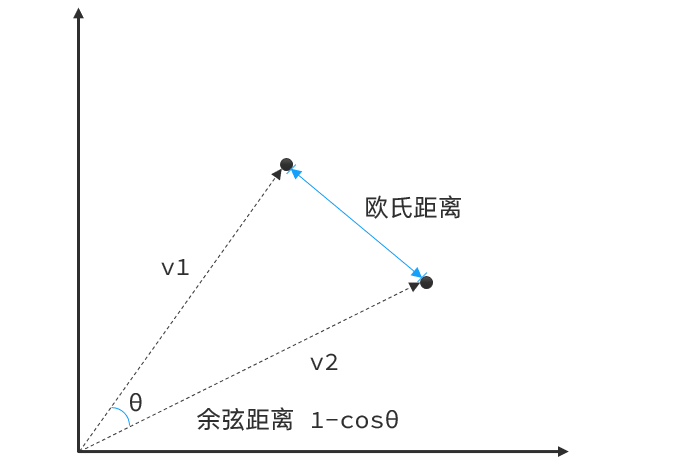

通常，两个向量之间距离越近，我们认为两个向量的相似度越高

所以，如果我们能把文本转为向量，就可以通过向量距离来判断文本的相似度了。

2.2.2 向量模型
现在，有不少的专门的向量模型，就可以实现将文本向量化。一个好的向量模型，就是要尽可能让文本含义相似的向量，在空间中距离更近：
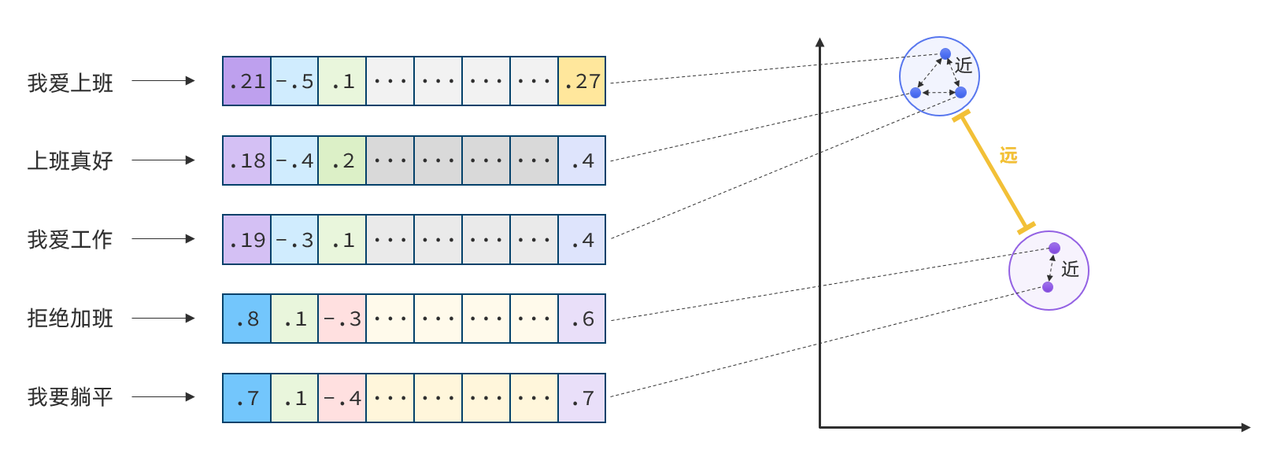

要使用基于向量模型的Store，我们就准备一个向量模型，用于将文本向量化。

阿里云百炼就有这样的模型，最新模型名为text-embedding-v4：

#### 2.2.3 定义基于向量的store
要定义基于向量相似度的store，就必须先创建向量模型，然后再初始化store，具体代码如下：

In [ ]:
from langgraph_cli.schemas import IndexConfig
from langchain_community.embeddings import DashScopeEmbeddings
import os

# 初始化向量模型
embedding_model = DashScopeEmbeddings(
    model="text-embedding-v4", dashscope_api_key=os.getenv("DASHSCOPE_API_KEY")
)

# 初始化store
memory_store = InMemoryStore(index=IndexConfig(
    embed=embedding_model,  # 向量模型
    dims=1024  # 向量维度
))

In [9]:
# ==================== 2.初始化一些数据 ====================
memory_store.put(("users",), "user_001", {
    "id": "user_001",
    "name": "张三",
    "department": "技术部",
    "clearance_level": 3
})

memory_store.put(("users",), "user_002", {
    "id": "user_002",
    "name": "李四",
    "department": "市场部",
    "clearance_level": 1
})

In [10]:
# ==================== 3.读取 ====================

# 3.1.基于get查询
user_data = memory_store.get(("users",), "user_001")
print(f"用户信息: {user_data.value if user_data else 'Not found'}")

# 3.2.基于search搜索数据
search_results = memory_store.search(
    ("users",),
    query="001",  # 基于字段语义检索
    limit=5
)
print(f"搜索结果数量: {len(search_results)}")
print(search_results)

用户信息: {'id': 'user_001', 'name': '张三', 'department': '技术部', 'clearance_level': 3}
搜索结果数量: 2
[Item(namespace=['users'], key='user_001', value={'id': 'user_001', 'name': '张三', 'department': '技术部', 'clearance_level': 3}, created_at='2026-06-07T11:53:14.462108+00:00', updated_at='2026-06-07T11:53:14.462110+00:00', score=0.3415490758450993), Item(namespace=['users'], key='user_002', value={'id': 'user_002', 'name': '李四', 'department': '市场部', 'clearance_level': 1}, created_at='2026-06-07T11:53:18.023037+00:00', updated_at='2026-06-07T11:53:18.023043+00:00', score=0.2891345529670016)]


可以看到搜索结果会有多个，并且每个都有一个score字段，也就是相似度得分，得分越高排名越靠前。

### 2.3 在tool中访问store
与state类似，LangChain中访问store通常也可以有两种场景：
- Tool
- 中间件
我们依然先学习tool中访问store，与state类似，在tool 中访问store也是通过runtime

依然使用上一小节的store为例，在tool中访问store要这样做：

In [11]:
from langchain.tools import tool, ToolRuntime

@tool
def get_user_info(user_id: str, runtime: ToolRuntime) -> str:
    """获取用户信息"""
    if runtime.store is None:
        return "Store not available"

    # 通过runtime获取store，读取其中的数据
    user_info = runtime.store.get(("users",), user_id)

    if user_info is None:
        return "没有找到用户"

    return f"用户信息: {user_info.value}"

### 2.4 给agent添加store
创建agent时需要指定store：

In [12]:
from langchain.messages import HumanMessage

# 在Agent中集成
agent = create_agent(
    model="deepseek-chat",
    tools=[get_user_info],
    store=memory_store  # 指定store的存储方式
)

response = agent.invoke({
    "messages": [HumanMessage("帮我查询user_001的信息")]
})
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

帮我查询user_001的信息
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_00_Z53yEYHfYQCRjU6Jr76X9324)
 Call ID: call_00_Z53yEYHfYQCRjU6Jr76X9324
  Args:
    user_id: user_001
================================= Tool Message =================================
Name: get_user_info

用户信息: {'id': 'user_001', 'name': '张三', 'department': '技术部', 'clearance_level': 3}
================================== Ai Message ==================================

以下是用户 **user_001** 的信息：

| 字段 | 内容 |
|------|------|
| **用户ID** | user_001 |
| **姓名** | 张三 |
| **部门** | 技术部 |
| **权限等级** | 3 级 |

如果您需要进一步了解该用户的详细信息或其他帮助，请随时告诉我！


## 3. Context（运行上下文）
Context用于在运行时传递配置参数、用户信息等会话临时数据，你可以自定义Context的数据结构。

例如，在系统中用户通常会先登录，然后访问agent，我们就可以把登录用户信息存入Context，方便后续获取用户信息。
### 3.1 定义Context Schema
首先，我们需要约定Context的数据结构，有两种方式：
- 方式一：使用@dataclass来定义
- 方式二：继承TypedDict

示例代码：

In [13]:
from dataclasses import dataclass


# 方式1：使用dataclass定义Context
@dataclass
class UserContext:
    """Agent运行时上下文"""
    user_id: str = ""


# 方式2：使用TypedDict定义Context
from typing_extensions import TypedDict


class UserContext2(TypedDict):
    """运行时上下文类型"""
    user_id: str

### 3.2 在Tool中使用Context
与state类似，我们同样可以在tool中利用runtime来访问Context：

In [15]:
from langchain.agents import create_agent

@tool
def get_users(runtime: ToolRuntime[UserContext]):
    """查询所有用户信息"""
    # 获取store
    store = runtime.store
    if store is None:
        return "Store not available"
    # 获取当前用户信息
    user_id = runtime.context.user_id
    if user_id is None:
        return "当前用户未登录，无法查看"

    user = store.get(("users",), user_id)
    if user is None:
        return "当前用户未登录，无法查看"

    # 校验权限，至少是3级权限
    user_info = dict(user.value)
    if user_info['clearance_level'] < 3:
        return "权限不足！"
    # 查询用户
    results = runtime.store.search(("users",))
    if results is None or len(results) == 0:
        return "未查询到用户"
    users = [item.value for item in results]
    return users


@tool
def get_user_preferences(runtime: ToolRuntime[UserContext]):
    """查询当前用户的偏好，根据偏好输出结果"""
    # 获取当前用户id
    user_id = runtime.context.user_id
    # 获取用户偏好
    user_preference = runtime.store.get(("preferences",), user_id)
    if user_preference is None:
        return "未查找到用户偏好信息"

    return user_preference.value

### 3.3 给Agent添加Context
在定义Agent时，需要指定我们创建好的Context：

In [16]:
# 创建Agent时指定context_schema
agent = create_agent(
    model="deepseek-chat",
    tools=[get_users, get_user_preferences],
    store=memory_store,
    context_schema=UserContext,  # 指定Context类型
    system_prompt="""
    # indentify
    你是一个热心的助手，你可以调用工具获取用户信息，用户偏好。
    # instruction
    请务必按照用户偏好风格展示结果。
    """
)

In [17]:
# 调用时通过Context传递用户信息
response = agent.invoke(
    {"messages": [HumanMessage("Hello, 帮我查询所有用户信息")]},
    context=UserContext(user_id="user_001")
)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Hello, 帮我查询所有用户信息
================================== Ai Message ==================================

好的，我来查询所有用户信息。
Tool Calls:
  get_users (call_00_64j0lQ2LRkBTaudbcupI5476)
 Call ID: call_00_64j0lQ2LRkBTaudbcupI5476
  Args:
================================= Tool Message =================================
Name: get_users

[{"id": "user_001", "name": "张三", "department": "技术部", "clearance_level": 3}, {"id": "user_002", "name": "李四", "department": "市场部", "clearance_level": 1}]
================================== Ai Message ==================================

好的，查询到所有用户信息如下：

| 用户ID | 姓名 | 部门 | 权限等级 |
|--------|------|------|---------|
| user_001 | **张三** | 技术部 | 3 |
| user_002 | **李四** | 市场部 | 1 |

目前系统中共有 **2位用户**：
- **张三**（技术部，权限等级3）
- **李四**（市场部，权限等级1）

另外，让我也查一下您的个人偏好，以便后续以您喜欢的方式为您服务。
Tool Calls:
  get_user_preferences (call_00_BS1bG49KNK3OHUklBSlU3285)
 Call ID: call_00_BS1bG49KNK3OHUklBSlU3285
  Args:
==

## 4. 总结
1. State（短期记忆）
  - 通过runtime.state参数访问
  - 用于保存会话历史消息、对话状态、计数等临时信息
  - 生命周期是当前会话
  - 存储方式：可以是InMemorySaver、也可以是数据库
2. Store（长期记忆）
  - 通过runtime.store访问
  - 用于拓展知识、用户偏好等信息
  - 生命周期跨越多个会话
  - 支持InMemoryStore和数据库存储
3. Context（运行时上下文）
  - 通过runtime.context访问
  - 用于传递用户ID、配置参数等
  - 生命周期是当前会话
  - 存储方式：基于内存